In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pyarrow
import arrow

In [4]:
institutions_df = pd.read_csv(
    'data/Most-Recent-Cohorts-Institution.csv.gz',
    usecols=[
        'OPEID6',
        'INSTNM',
        'CITY',
        'STABBR',
        'FTFTPCTPELL',
        'TUITIONFEE_IN',
        'TUITIONFEE_OUT',
        'ADM_RATE',
        'NPT4_PUB',
        'NPT4_PRIV',
        'NPT41_PUB',
        'NPT41_PRIV',
        'NPT45_PUB',
        'NPT45_PRIV',
        'MD_EARN_WNE_P10',
        'C100_4',
    ],
    engine='pyarrow'
)

institutions_df

,OPEID6,INSTNM,CITY,STABBR,FTFTPCTPELL,TUITIONFEE_IN,TUITIONFEE_OUT,ADM_RATE,NPT4_PUB,NPT4_PRIV,NPT41_PUB,NPT41_PRIV,NPT45_PUB,NPT45_PRIV,MD_EARN_WNE_P10,C100_4
0,1002,Alabama A & M University,Normal,AL,0.6925,10024.0,18634.0,0.8965,15529.0,NaN,14694.0,NaN,20483.0,NaN,36339.0,0.1052
1,1052,University of Alabama at Birmingham,Birmingham,AL,0.3563,8568.0,20400.0,0.8060,16530.0,NaN,13443.0,NaN,19717.0,NaN,46990.0,0.3816
2,25034,Amridge University,Montgomery,AL,0.6667,6950.0,6950.0,NaN,NaN,17618.0,NaN,17385.0,NaN,NaN,37895.0,0.2500
3,1055,University of Alabama in Huntsville,Huntsville,AL,0.2304,11338.0,23734.0,0.7711,17208.0,NaN,13631.0,NaN,19862.0,NaN,54361.0,0.3109
4,1005,Alabama State University,Montgomery,AL,0.7590,11068.0,19396.0,0.9888,19534.0,NaN,19581.0,NaN,17559.0,NaN,32084.0,0.1462
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6657,3329,Pennsylvania State University-Penn State Wilke...,Lehman,PA,NaN,13604.0,22196.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6658,3329,Pennsylvania State University-Penn State York,York,PA,NaN,14486.0,23476.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6659,3329,Pennsylvania State University-Penn State Great...,Malvern,PA,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6660,3329,Pennsylvania State University-Penn State Harri...,Middletown,PA,NaN,15216.0,24926.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
fields_of_study_df = pd.read_csv(
    'data/FieldOfStudyData1718_1819_PP.csv.gz',
    usecols=[
        'OPEID6',
        'INSTNM',
        'CREDDESC',
        'CIPDESC',
        'CONTROL',
    ],
    engine='pyarrow'
)

fields_of_study_df

,OPEID6,INSTNM,CREDDESC,CIPDESC,CONTROL
0,1002,Alabama A & M University,Bachelors Degree,"Agriculture, General.",Public
1,1002,Alabama A & M University,Bachelors Degree,Animal Sciences.,Public
2,1002,Alabama A & M University,Bachelors Degree,Food Science and Technology.,Public
3,1002,Alabama A & M University,Master's Degree,Food Science and Technology.,Public
4,1002,Alabama A & M University,Doctoral Degree,Food Science and Technology.,Public
...,...,...,...,...,...
224844,42640,California Southern University,Undergraduate Certificate or Diploma,"Clinical, Counseling and Applied Psychology.","Private, for-profit"
224845,42640,California Southern University,Doctoral Degree,"Clinical, Counseling and Applied Psychology.","Private, for-profit"
224846,42753,Zion Massage College,Undergraduate Certificate or Diploma,Somatic Bodywork and Related Therapeutic Servi...,"Private, for-profit"
224847,42837,Oregon Coast Community College,Associate's Degree,"Registered Nursing, Nursing Administration, Nu...",Public


In [6]:
len(institutions_df) - institutions_df.count()

OPEID6                0
INSTNM                0
CITY                  0
STABBR                0
FTFTPCTPELL        1123
TUITIONFEE_IN      2832
TUITIONFEE_OUT     2832
ADM_RATE           4702
NPT4_PUB           4834
NPT4_PRIV          3097
NPT41_PUB          4839
NPT41_PRIV         3156
NPT45_PUB          5358
NPT45_PRIV         4853
MD_EARN_WNE_P10    1637
C100_4             4655
dtype: int64

In [9]:
institutions_df.groupby('STABBR')['STABBR'].count().sort_values(ascending=False).head(1)

STABBR
CA    705
Name: STABBR, dtype: int64

In [11]:
institutions_df.groupby(by=['STABBR', 'CITY'])['STABBR'].count().sort_values(ascending=False).head(1)

STABBR  CITY    
NY      New York    81
Name: STABBR, dtype: int64

In [13]:
old_memory = institutions_df.memory_usage(deep=True).sum()
print(f'{old_memory:,}')

1,945,775


In [14]:
for col in ['STABBR', 'CITY']:
    institutions_df[col] = institutions_df[col].astype('category')

In [15]:
new_memory = institutions_df.memory_usage(deep=True).sum()
print(f'{new_memory:,}')

1,453,116


In [17]:
print(f'{old_memory - new_memory:,}')

492,659


In [19]:
fields_of_study_df.head()

,OPEID6,INSTNM,CREDDESC,CIPDESC,CONTROL
0,1002,Alabama A & M University,Bachelors Degree,"Agriculture, General.",Public
1,1002,Alabama A & M University,Bachelors Degree,Animal Sciences.,Public
2,1002,Alabama A & M University,Bachelors Degree,Food Science and Technology.,Public
3,1002,Alabama A & M University,Master's Degree,Food Science and Technology.,Public
4,1002,Alabama A & M University,Doctoral Degree,Food Science and Technology.,Public


In [21]:
pd.Series(fields_of_study_df['CREDDESC'].unique())

0                        Bachelors Degree
1                         Master's Degree
2                         Doctoral Degree
3       Graduate/Professional Certificate
4               First Professional Degree
5    Undergraduate Certificate or Diploma
6                      Associate's Degree
7          Post-baccalaureate Certificate
dtype: object

<Axes: xlabel='INSTNM'>

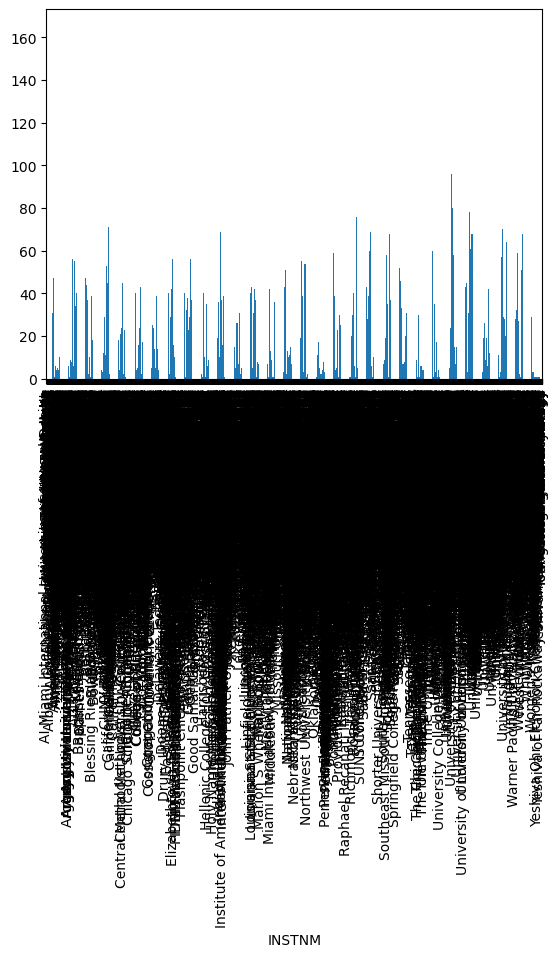

In [37]:
fields_of_study_df.loc[fields_of_study_df['CREDDESC'] == 'Bachelors Degree'].groupby(by=['INSTNM'])['INSTNM'].count().plot.bar()

<Axes: ylabel='Frequency'>

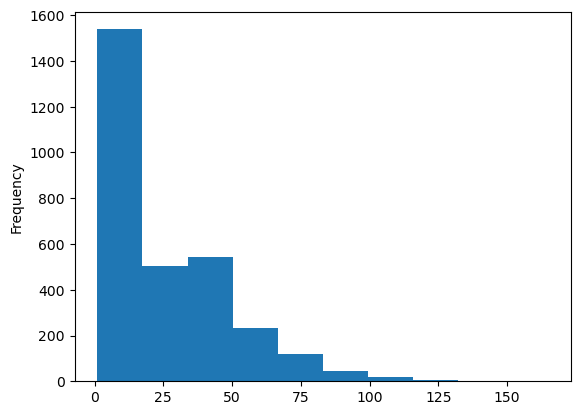

In [58]:
fields_of_study_df.loc[fields_of_study_df['CREDDESC'] == 'Bachelors Degree'].groupby(by=['INSTNM'])['INSTNM'].count().plot.hist()

In [39]:
len(fields_of_study_df) - fields_of_study_df.count()

OPEID6      0
INSTNM      0
CREDDESC    0
CIPDESC     0
CONTROL     0
dtype: int64

<Axes: xlabel='CREDDESC'>

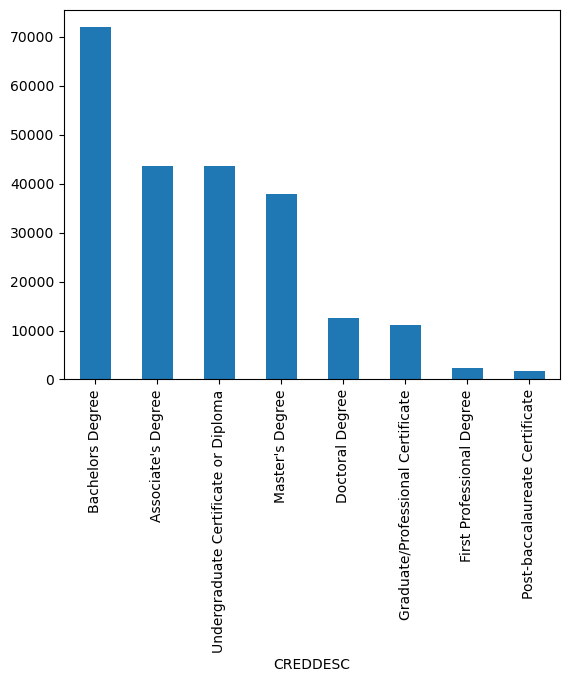

In [60]:
fields_of_study_df['CREDDESC'].value_counts().plot.bar()

In [45]:
fields_of_study_df.loc[fields_of_study_df['CREDDESC'] == 'Bachelors Degree', 'INSTNM'].value_counts().head(1)

INSTNM
Westminster College    165
Name: count, dtype: int64

<Axes: ylabel='Frequency'>

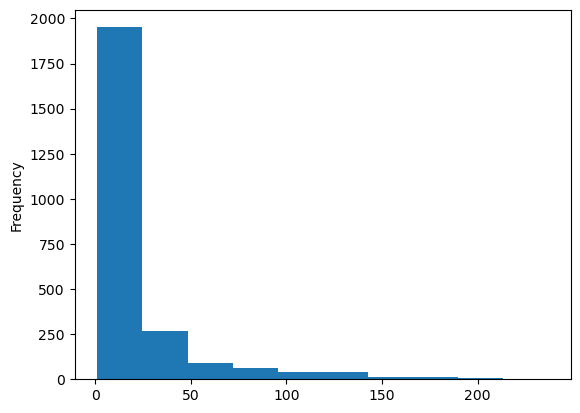

In [61]:
fields_of_study_df.loc[fields_of_study_df['CREDDESC'].isin(["Master's Degree", 'Doctoral Degree']), 'INSTNM'].value_counts().plot.hist()

In [55]:
fields_of_study_df.loc[fields_of_study_df['CREDDESC'].isin(["Master's Degree", 'Doctoral Degree']), 'INSTNM'].value_counts().head(1)

INSTNM
University of Washington-Seattle Campus    237
Name: count, dtype: int64

In [70]:
bachelor = fields_of_study_df.loc[fields_of_study_df['CREDDESC'] == 'Bachelors Degree', 'INSTNM'].value_counts().to_frame().reset_index()

In [71]:
bachelor

,INSTNM,count
0,Westminster College,165
1,Pennsylvania State University-Main Campus,141
2,University of Washington-Seattle Campus,137
3,Ohio State University-Main Campus,126
4,Bethel University,125
...,...,...
3001,Yeshiva of the Telshe Alumni,1
3002,Career Networks Institute,1
3003,Carolinas College of Health Sciences,1
3004,City College-Miami,1


In [72]:
master = fields_of_study_df.loc[fields_of_study_df['CREDDESC'].isin(["Master's Degree", 'Doctoral Degree']), 'INSTNM'].value_counts().to_frame().reset_index()

In [73]:
master

,INSTNM,count
0,University of Washington-Seattle Campus,237
1,Pennsylvania State University-Main Campus,230
2,New York University,226
3,University of Minnesota-Twin Cities,205
4,Ohio State University-Main Campus,200
...,...,...
2482,Southwest University of Visual Arts-Albuquerque,1
2483,Soka University of America,1
2484,Watkins College of Art Design & Film,1
2485,Herzing University-Orlando,1


In [75]:
len(bachelor.loc[~bachelor['INSTNM'].isin(master['INSTNM'])])

923

In [76]:
len(master.loc[~master['INSTNM'].isin(bachelor['INSTNM'])])

404

In [82]:
len(fields_of_study_df.loc[(fields_of_study_df['CREDDESC'] == 'Bachelors Degree') & (fields_of_study_df['CIPDESC'].str.contains('Computer Science')), 'INSTNM'].value_counts())

762

In [81]:
fields_of_study_df.loc[(fields_of_study_df['CREDDESC'] == 'Bachelors Degree') & (fields_of_study_df['CIPDESC'].str.contains('Computer Science')), 'CONTROL'].value_counts()

CONTROL
Private, nonprofit     501
Public                 273
Foreign                 32
Private, for-profit     18
Name: count, dtype: int64

<Axes: ylabel='count'>

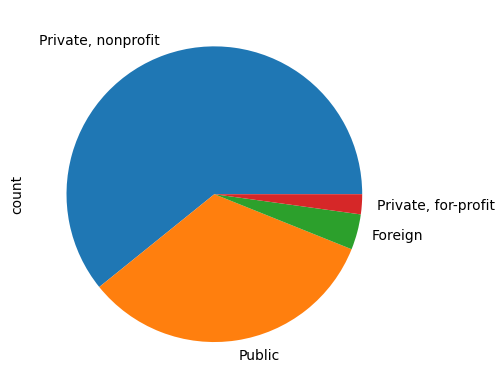

In [83]:
fields_of_study_df.loc[(fields_of_study_df['CREDDESC'] == 'Bachelors Degree') & (fields_of_study_df['CIPDESC'].str.contains('Computer Science')), 'CONTROL'].value_counts().plot.pie()

In [84]:
sci = fields_of_study_df.loc[(fields_of_study_df['CREDDESC'] == 'Bachelors Degree') & (fields_of_study_df['CIPDESC'].str.contains('Computer Science'))]

In [85]:
sci

,OPEID6,INSTNM,CREDDESC,CIPDESC,CONTROL
360,1005,Alabama State University,Bachelors Degree,Computer Science.,Public
671,8310,Auburn University at Montgomery,Bachelors Degree,Computer Science.,Public
1110,1003,Faulkner University,Bachelors Degree,Computer Science.,"Private, nonprofit"
1936,1033,Oakwood University,Bachelors Degree,Computer Science.,"Private, nonprofit"
2040,1036,Samford University,Bachelors Degree,Computer Science.,"Private, nonprofit"
...,...,...,...,...,...
223531,30914,University of Wollongong,Bachelors Degree,Computer Science.,Foreign
223619,30961,La Trobe University,Bachelors Degree,Computer Science.,Foreign
223971,34353,Anglia Ruskin University,Bachelors Degree,Computer Science.,Foreign
224154,35173,University of Brighton,Bachelors Degree,Computer Science.,Foreign


In [88]:
sci.merge(right=institutions_df[['OPEID6', 'TUITIONFEE_OUT']], on=['OPEID6'], how='left')['TUITIONFEE_OUT'].agg(['min', 'median', 'mean', 'max'])

min        3154.000000
median    24320.000000
mean      26996.482002
max       61671.000000
Name: TUITIONFEE_OUT, dtype: float64

In [91]:
sci.merge(right=institutions_df[['OPEID6', 'TUITIONFEE_OUT']], on=['OPEID6'], how='left').groupby(by=['CONTROL'])['TUITIONFEE_OUT'].agg(['min', 'median', 'mean', 'max']).dropna().transpose()

CONTROL,"Private, for-profit","Private, nonprofit",Public
min,8280.000000,4300.000000,3154.000000
median,12233.000000,34245.000000,21312.000000
mean,12359.161765,33789.982818,22333.437055
max,25820.000000,61671.000000,47220.000000


In [93]:
institutions_df[['ADM_RATE', 'TUITIONFEE_OUT']].corr()

,ADM_RATE,TUITIONFEE_OUT
ADM_RATE,1.000000,-0.309658
TUITIONFEE_OUT,-0.309658,1.000000


<Axes: xlabel='TUITIONFEE_OUT', ylabel='ADM_RATE'>

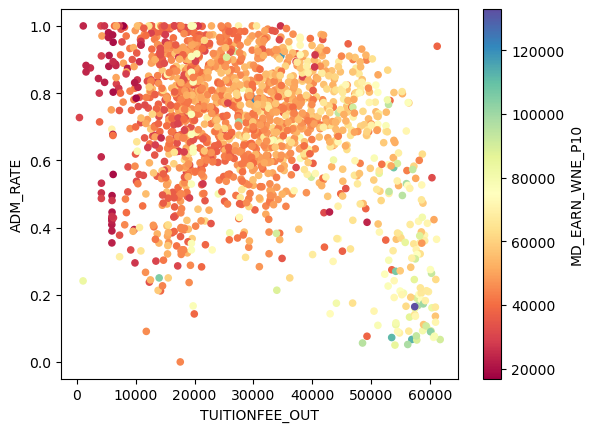

In [96]:
institutions_df[['ADM_RATE', 'TUITIONFEE_OUT', 'MD_EARN_WNE_P10']].plot.scatter(x='TUITIONFEE_OUT', y='ADM_RATE', c='MD_EARN_WNE_P10', colormap='Spectral')

In [105]:
fst_quantile = institutions_df.loc[(institutions_df['TUITIONFEE_OUT'] > institutions_df['TUITIONFEE_OUT'].quantile(0.75)) & (institutions_df['FTFTPCTPELL'] > institutions_df['FTFTPCTPELL'].quantile(0.75))]

In [106]:
fst_quantile[['INSTNM', 'CITY', 'STABBR']].drop_duplicates().sort_values(by='INSTNM')

,INSTNM,CITY,STABBR
5491,Antioch College,Yellow Springs,OH
1206,Berea College,Berea,KY
1930,Berkeley College-Woodland Park,Woodland Park,NJ
1932,Bloomfield College,Bloomfield,NJ
2334,Chowan University,Murfreesboro,NC
1543,Dorsey College,Madison Heights,MI
3758,Dorsey College-Roseville,Roseville,MI
5138,Dorsey College-Saginaw,Saginaw,MI
3734,Dorsey College-Wayne,Wayne,MI
1542,Dorsey School of Business-Madison Heights,Madison Heights,MI


In [107]:
len(fst_quantile[['INSTNM', 'CITY', 'STABBR']].drop_duplicates().sort_values(by='INSTNM'))

18

In [113]:
institutions_df[['NPT41_PUB', 'NPT41_PRIV']].loc[institutions_df['NPT41_PUB'].isnull() & institutions_df['NPT41_PRIV'].isnull()]

,NPT41_PUB,NPT41_PRIV
7,NaN,NaN
23,NaN,NaN
53,NaN,NaN
80,NaN,NaN
90,NaN,NaN
...,...,...
6657,NaN,NaN
6658,NaN,NaN
6659,NaN,NaN
6660,NaN,NaN


In [114]:
institutions_df[['NPT41_PUB', 'NPT41_PRIV']].loc[institutions_df['NPT41_PUB'].notnull() & institutions_df['NPT41_PRIV'].notnull()]

,NPT41_PUB,NPT41_PRIV


In [119]:
len(institutions_df[['NPT41_PUB', 'NPT41_PRIV']].dropna(thresh=1).loc[(institutions_df['NPT41_PUB'] < 0) | (institutions_df['NPT41_PRIV'] < 0)])

12

In [120]:
tmp = institutions_df[['NPT41_PUB', 'NPT41_PRIV']]

In [121]:
tmp

,NPT41_PUB,NPT41_PRIV
0,14694.0,NaN
1,13443.0,NaN
2,NaN,17385.0
3,13631.0,NaN
4,19581.0,NaN
...,...,...
6657,NaN,NaN
6658,NaN,NaN
6659,NaN,NaN
6660,NaN,NaN


In [122]:
def my_coalesce(first, second):
    if pd.isnull(first):
        return second
    else:
        return first

In [125]:
tmp.loc[:, 'NPT41'] = tmp.apply(lambda row: my_coalesce(row['NPT41_PUB'], row['NPT41_PRIV']), axis=1)

In [127]:
len(tmp.loc[tmp['NPT41'] < 0])

12

In [128]:
institutions_df.head()

,OPEID6,INSTNM,CITY,STABBR,FTFTPCTPELL,TUITIONFEE_IN,TUITIONFEE_OUT,ADM_RATE,NPT4_PUB,NPT4_PRIV,NPT41_PUB,NPT41_PRIV,NPT45_PUB,NPT45_PRIV,MD_EARN_WNE_P10,C100_4
0,1002,Alabama A & M University,Normal,AL,0.6925,10024.0,18634.0,0.8965,15529.0,NaN,14694.0,NaN,20483.0,NaN,36339.0,0.1052
1,1052,University of Alabama at Birmingham,Birmingham,AL,0.3563,8568.0,20400.0,0.8060,16530.0,NaN,13443.0,NaN,19717.0,NaN,46990.0,0.3816
2,25034,Amridge University,Montgomery,AL,0.6667,6950.0,6950.0,NaN,NaN,17618.0,NaN,17385.0,NaN,NaN,37895.0,0.2500
3,1055,University of Alabama in Huntsville,Huntsville,AL,0.2304,11338.0,23734.0,0.7711,17208.0,NaN,13631.0,NaN,19862.0,NaN,54361.0,0.3109
4,1005,Alabama State University,Montgomery,AL,0.7590,11068.0,19396.0,0.9888,19534.0,NaN,19581.0,NaN,17559.0,NaN,32084.0,0.1462


In [135]:
fields_of_study_df.groupby(by=['INSTNM', 'CONTROL'])['OPEID6'].count().to_frame().reset_index().groupby(by=['INSTNM'])['CONTROL'].apply(set).str.len().value_counts()

CONTROL
1    7267
2      14
3       1
Name: count, dtype: int64

In [140]:
fields_of_study_df.groupby(by=['INSTNM', 'CONTROL'])['OPEID6'].count().to_frame().reset_index().groupby(by=['INSTNM'])['CONTROL'].apply(set).str.len().loc[lambda x: x >= 2].sort_values(ascending=False)

INSTNM
Columbia College                       3
Central School of Practical Nursing    2
Century College                        2
Davis College                          2
Everest College                        2
Everest Institute                      2
King's College                         2
Lincoln University                     2
Northwestern College                   2
Shepherd University                    2
Skyline College                        2
Southwestern College                   2
St Joseph School of Nursing            2
Western Technical College              2
WyoTech                                2
Name: CONTROL, dtype: int64

In [141]:
fields_of_study_df.loc[fields_of_study_df['INSTNM'] == 'Columbia College']

,OPEID6,INSTNM,CREDDESC,CIPDESC,CONTROL
14372,7707,Columbia College,Associate's Degree,Agricultural Production Operations.,Public
14373,7707,Columbia College,Undergraduate Certificate or Diploma,Natural Resources Conservation and Research.,Public
14374,7707,Columbia College,Associate's Degree,Natural Resources Conservation and Research.,Public
14375,7707,Columbia College,Undergraduate Certificate or Diploma,Forestry.,Public
14376,7707,Columbia College,Associate's Degree,Forestry.,Public
...,...,...,...,...,...
207530,41273,Columbia College,Associate's Degree,Business Operations Support and Assistant Serv...,"Private, for-profit"
210471,41273,Columbia College,Undergraduate Certificate or Diploma,Cosmetology and Related Personal Grooming Serv...,"Private, for-profit"
210472,41273,Columbia College,Associate's Degree,Cosmetology and Related Personal Grooming Serv...,"Private, for-profit"
210473,41273,Columbia College,Undergraduate Certificate or Diploma,"English Language and Literature, General.","Private, for-profit"


In [144]:
institutions_df[['NPT41_PUB', 'NPT45_PUB']].loc[institutions_df['NPT41_PUB'].isnull() & institutions_df['NPT45_PUB'].notnull()]

,NPT41_PUB,NPT45_PUB
3980,NaN,25160.0


In [145]:
institutions_df[['NPT41_PUB', 'NPT45_PUB']].loc[institutions_df['NPT41_PUB'].notnull() & institutions_df['NPT45_PUB'].isnull()]

,NPT41_PUB,NPT45_PUB
11,2686.0,NaN
18,714.0,NaN
20,3733.0,NaN
24,5384.0,NaN
25,2902.0,NaN
...,...,...
5780,7397.0,NaN
5790,1536.0,NaN
5819,32019.0,NaN
5887,7377.0,NaN


In [147]:
pub = institutions_df[['NPT41_PUB', 'NPT45_PUB']].dropna()

In [148]:
pub.loc[:, 'share'] = pub['NPT41_PUB'] / pub['NPT45_PUB']

In [151]:
pub['share'].mean() * 100

np.float64(52.33221766529079)

In [152]:
institutions_df[['NPT41_PRIV', 'NPT45_PRIV']].loc[institutions_df['NPT41_PRIV'].isnull() & institutions_df['NPT45_PRIV'].notnull()]

,NPT41_PRIV,NPT45_PRIV
271,NaN,42928.0
944,NaN,29504.0
988,NaN,36624.0
1126,NaN,23978.0
1321,NaN,23255.0
1482,NaN,35065.0
1595,NaN,9644.0
2232,NaN,33896.0
2775,NaN,11198.0
4158,NaN,21385.0


In [153]:
institutions_df[['NPT41_PRIV', 'NPT45_PRIV']].loc[institutions_df['NPT41_PRIV'].notnull() & institutions_df['NPT45_PRIV'].isnull()]

,NPT41_PRIV,NPT45_PRIV
2,17385.0,NaN
17,12505.0,NaN
21,25984.0,NaN
47,26138.0,NaN
49,19948.0,NaN
...,...,...
6095,24106.0,NaN
6096,24382.0,NaN
6097,4596.0,NaN
6098,19180.0,NaN


In [154]:
prv = institutions_df[['NPT41_PRIV', 'NPT45_PRIV']].dropna()

In [156]:
prv.loc[:, 'share'] = prv['NPT41_PRIV'] / prv['NPT45_PRIV']

In [158]:
prv['share'].mean() * 100

np.float64(71.49056194364869)

In [179]:
len(institutions_df.loc[(institutions_df['NPT4_PUB'] <= institutions_df['NPT4_PUB'].quantile(0.25)) & (institutions_df['MD_EARN_WNE_P10'] >= institutions_df['MD_EARN_WNE_P10'].quantile(0.75))])

22

In [180]:
len(institutions_df.loc[(institutions_df['NPT4_PRIV'] <= institutions_df['NPT4_PRIV'].quantile(0.25)) & (institutions_df['MD_EARN_WNE_P10'] >= institutions_df['MD_EARN_WNE_P10'].quantile(0.75))])

30

In [164]:
institutions_df[['ADM_RATE', 'C100_4']].corr()

,ADM_RATE,C100_4
ADM_RATE,1.000000,-0.336871
C100_4,-0.336871,1.000000


In [168]:
fields_of_study_df.merge(right=institutions_df[['OPEID6', 'MD_EARN_WNE_P10']], on='OPEID6', how='left').groupby('CONTROL')['MD_EARN_WNE_P10'].mean().dropna().sort_values(ascending=False)

CONTROL
Private, nonprofit     52539.363062
Public                 46682.056312
Private, for-profit    38164.132933
Name: MD_EARN_WNE_P10, dtype: float64

In [182]:
institutions_df[['OPEID6', 'MD_EARN_WNE_P10']].merge(right=fields_of_study_df.groupby('OPEID6')['CONTROL'].min(), on='OPEID6', how='left').groupby('CONTROL')['MD_EARN_WNE_P10'].mean().dropna().sort_values(ascending=False)

CONTROL
Private, nonprofit     48530.408744
Public                 40314.442820
Private, for-profit    30474.754943
Name: MD_EARN_WNE_P10, dtype: float64

In [169]:
league = [
    'Harvard University',
    'Massachusetts Institute of Technology',
    'Yale University',
    'Columbia University in the City of New York',
    'Brown University',
    'Stanford University',
    'University of Chicago',
    'Darthmouth College',
    'University of Pennsylvania',
    'Cornell Univesity',
    'Princeton University'
]

In [170]:
institutions_df.loc[institutions_df['INSTNM'].isin(league), 'MD_EARN_WNE_P10'].mean()

np.float64(91896.88888888889)

In [174]:
institutions_df.query('NPT4_PRIV.notnull() or NPT41_PRIV.notnull() or NPT45_PRIV.notnull()')['MD_EARN_WNE_P10'].mean()

np.float64(38014.8627671541)

In [176]:
institutions_df.groupby(by=['STABBR'])['MD_EARN_WNE_P10'].mean().dropna().sort_values(ascending=False)

/var/folders/d6/q237b0c90bqfq_8yty4yh1v40000gn/T/ipykernel_1896/1169126800.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  institutions_df.groupby(by=['STABBR'])['MD_EARN_WNE_P10'].mean().dropna().sort_values(ascending=False)


STABBR
MA    53234.396226
RI    50432.789474
DC    49081.470588
CT    48662.017857
VT    48383.857143
NY    47584.653199
NH    46540.791667
WA    44594.678161
PA    44265.733083
MN    43821.510204
MD    42875.716418
NJ    42797.201754
CA    42634.263858
AK    42270.714286
NE    41762.105263
HI    41685.000000
WI    41674.013514
VA    40912.412698
NV    40906.821429
IN    40777.910714
DE    40764.230769
IL    40686.659459
ME    40152.714286
OR    40122.290323
KS    39788.314286
IA    39753.275362
MO    39730.024793
CO    39542.411765
ND    39095.136364
SD    38882.434783
OH    38781.415254
UT    37965.850000
VI    37808.000000
GA    37158.140000
WY    36911.700000
TX    36634.606250
AL    36591.563380
AZ    36405.657534
MI    36394.244898
NC    35727.823529
FL    35490.414545
TN    35184.229508
SC    35074.630952
NM    34865.472222
MT    34436.777778
WV    34304.629032
OK    33970.271739
KY    33943.357143
LA    32442.834951
ID    32142.440000
MS    31300.120000
AR    31120.346667
MH   

<Axes: xlabel='STABBR'>

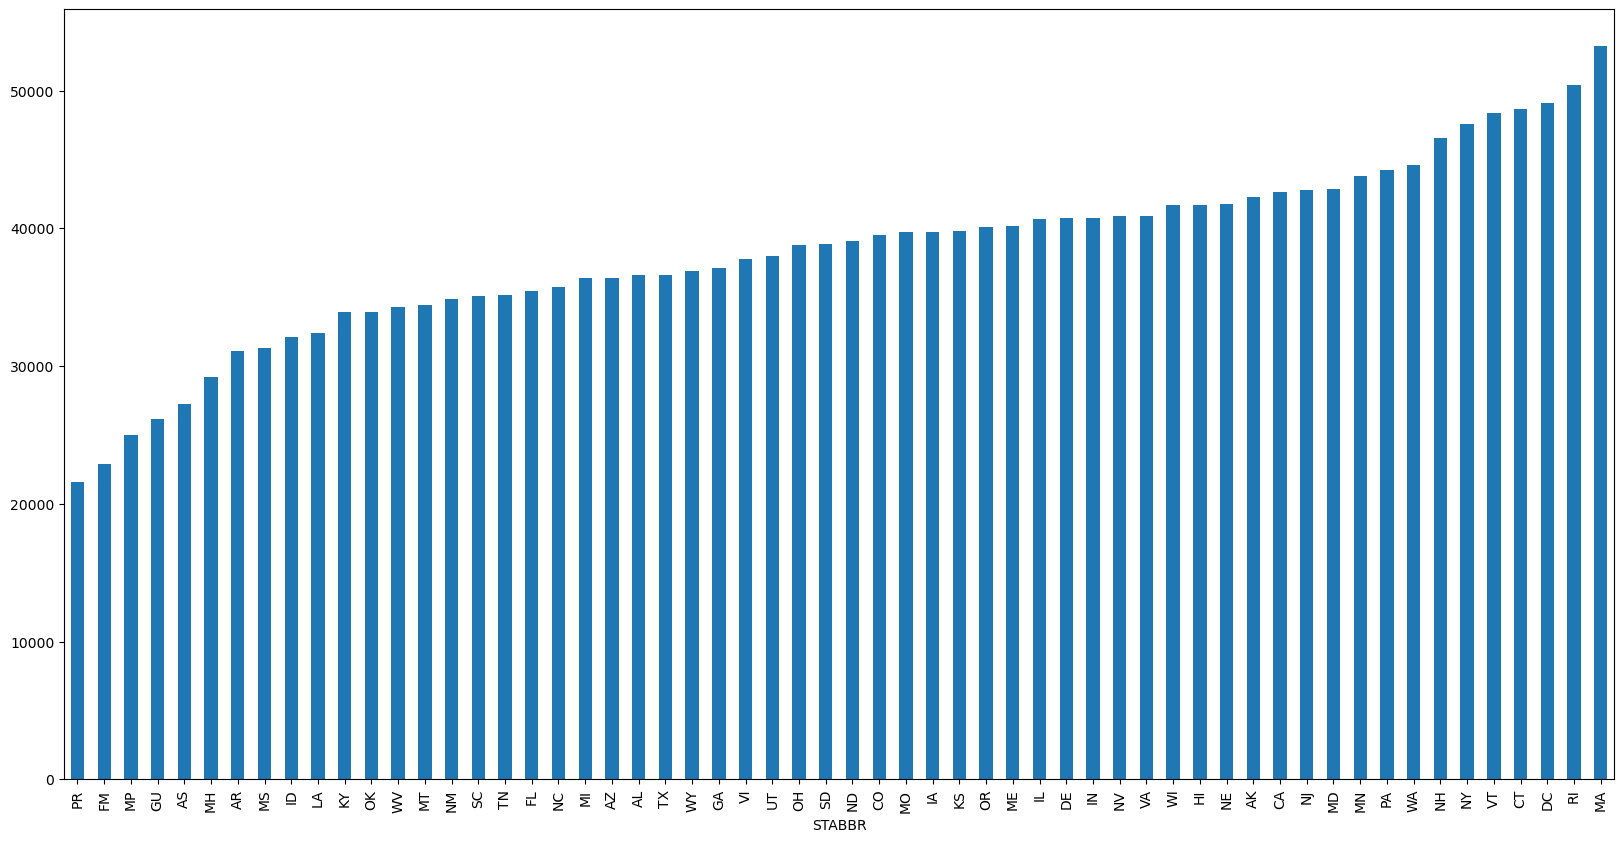

In [192]:
institutions_df[['STABBR', 'MD_EARN_WNE_P10']].groupby(by=['STABBR'], observed=True)['MD_EARN_WNE_P10'].mean().dropna().sort_values().plot.bar(figsize=(20, 10))

<Axes: >

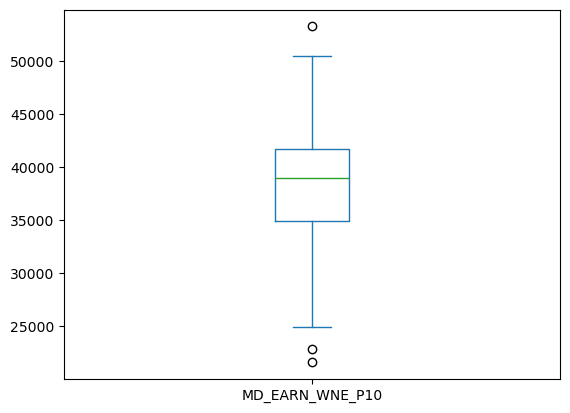

In [198]:
institutions_df[['STABBR', 'MD_EARN_WNE_P10']].groupby(by=['STABBR'], observed=True)['MD_EARN_WNE_P10'].mean().dropna().sort_values().plot.box()